In [24]:
!pip -q install gdown

import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

DATA_DIR = Path("data")
OUTPUT_DIR = Path("outputs")
DATA_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

HIST_FILE_ID = "1IAfLZwu6rJzyWKgBToqwSmmVYU6VbjVs"
FG_FILE_ID = "1PgQC0tO8XN-wqkNyghWc_-mnrYv_nhSf"

hist_path = DATA_DIR / "historical_data.csv"
fg_path = DATA_DIR / "fear_greed_index.csv"

# Download from Google Drive if files are not already present
if not hist_path.exists() or not fg_path.exists():
    try:
        import gdown
        if not hist_path.exists():
            gdown.download(id=HIST_FILE_ID, output=str(hist_path), quiet=False, fuzzy=True)
        if not fg_path.exists():
            gdown.download(id=FG_FILE_ID, output=str(fg_path), quiet=False, fuzzy=True)
    except Exception as e:
        print("Automatic download failed:", e)
        print("Please upload historical_data.csv and fear_greed_index.csv manually into the data/ folder.")

hist = pd.read_csv(hist_path)
fg = pd.read_csv(fg_path)

print("Historical data shape:", hist.shape)
print("Fear/Greed data shape:", fg.shape)
display(hist.head())
display(fg.head())

Historical data shape: (211224, 16)
Fear/Greed data shape: (2644, 4)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [25]:
def clean_column_name(col):
    col = str(col).strip()
    col = re.sub(r"[^0-9a-zA-Z]+", "_", col)
    col = re.sub(r"_+", "_", col).strip("_").lower()
    return col

hist = hist.copy()
fg = fg.copy()

hist.columns = [clean_column_name(c) for c in hist.columns]
fg.columns = [clean_column_name(c) for c in fg.columns]

print("Historical columns:")
print(hist.columns.tolist())
print("Fear/Greed columns:")
print(fg.columns.tolist())

Historical columns:
['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side', 'timestamp_ist', 'start_position', 'direction', 'closed_pnl', 'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id', 'timestamp']
Fear/Greed columns:
['timestamp', 'value', 'classification', 'date']


In [26]:
def find_col(df, candidates, required=True):
    cols = list(df.columns)
    for cand in candidates:
        cand_clean = clean_column_name(cand)
        if cand_clean in cols:
            return cand_clean
    for cand in candidates:
        cand_clean = clean_column_name(cand)
        matches = [c for c in cols if cand_clean in c or c in cand_clean]
        if matches:
            return matches[0]
    if required:
        raise ValueError(f"Could not find any of these columns: {candidates}. Available columns: {cols}")
    return None

# Sentiment columns
fg_date_col = find_col(fg, ["date", "timestamp", "time"])
fg_class_col = find_col(fg, ["classification", "sentiment", "value_classification", "fear_greed"])

# Trader data columns
account_col = find_col(hist, ["account", "wallet", "user", "address"], required=False)
symbol_col = find_col(hist, ["symbol", "coin", "asset", "token"], required=False)
time_col = find_col(hist, ["time", "timestamp", "datetime", "date"], required=True)
price_col = find_col(hist, ["execution_price", "price", "exec_price"], required=False)
size_usd_col = find_col(hist, ["size_usd", "usd_size", "notional", "value_usd"], required=False)
size_token_col = find_col(hist, ["size", "size_tokens", "qty", "quantity", "amount"], required=False)
side_col = find_col(hist, ["side", "buy_sell"], required=False)
pnl_col = find_col(hist, ["closedpnl", "closed_pnl", "pnl", "closed_profit_loss"], required=True)
leverage_col = find_col(hist, ["leverage", "lev"], required=False)
fee_col = find_col(hist, ["fee", "fees"], required=False)

print("Detected columns:")
for name, value in {
    "fg_date_col": fg_date_col,
    "fg_class_col": fg_class_col,
    "account_col": account_col,
    "symbol_col": symbol_col,
    "time_col": time_col,
    "price_col": price_col,
    "size_usd_col": size_usd_col,
    "size_token_col": size_token_col,
    "side_col": side_col,
    "pnl_col": pnl_col,
    "leverage_col": leverage_col,
    "fee_col": fee_col,
}.items():
    print(f"{name}: {value}")

Detected columns:
fg_date_col: date
fg_class_col: classification
account_col: account
symbol_col: coin
time_col: timestamp
price_col: execution_price
size_usd_col: size_usd
size_token_col: size_tokens
side_col: side
pnl_col: closed_pnl
leverage_col: None
fee_col: fee


In [27]:
def parse_datetime_flexible(series):
    s = series.copy()
    numeric = pd.to_numeric(s, errors="coerce")
    numeric_ratio = numeric.notna().mean()

    if numeric_ratio > 0.8:
        median_val = numeric.dropna().median()
        if median_val > 1e14:      # nanoseconds
            return pd.to_datetime(numeric, unit="ns", errors="coerce", utc=True)
        elif median_val > 1e11:    # milliseconds
            return pd.to_datetime(numeric, unit="ms", errors="coerce", utc=True)
        elif median_val > 1e8:     # seconds
            return pd.to_datetime(numeric, unit="s", errors="coerce", utc=True)

    dt = pd.to_datetime(s, errors="coerce", utc=True)
    if dt.notna().mean() < 0.5:
        dt = pd.to_datetime(s, errors="coerce", dayfirst=True, utc=True)
    return dt

# Clean sentiment data
fg_clean = fg[[fg_date_col, fg_class_col]].copy()
fg_clean.columns = ["date_raw", "classification"]
fg_clean["date"] = parse_datetime_flexible(fg_clean["date_raw"]).dt.date
fg_clean["classification"] = fg_clean["classification"].astype(str).str.strip().str.title()
fg_clean = fg_clean.dropna(subset=["date", "classification"]).drop_duplicates(subset=["date"], keep="last")

# Clean historical data
trades = hist.copy()
trades["trade_datetime"] = parse_datetime_flexible(trades[time_col])
trades["date"] = trades["trade_datetime"].dt.date
trades["closed_pnl"] = pd.to_numeric(trades[pnl_col], errors="coerce")

if price_col:
    trades["execution_price"] = pd.to_numeric(trades[price_col], errors="coerce")
else:
    trades["execution_price"] = np.nan

if size_usd_col:
    trades["size_usd"] = pd.to_numeric(trades[size_usd_col], errors="coerce")
elif size_token_col and price_col:
    trades["size_usd"] = pd.to_numeric(trades[size_token_col], errors="coerce").abs() * pd.to_numeric(trades[price_col], errors="coerce")
else:
    trades["size_usd"] = np.nan

if size_token_col:
    trades["size_tokens"] = pd.to_numeric(trades[size_token_col], errors="coerce")
else:
    trades["size_tokens"] = np.nan

if leverage_col:
    trades["leverage"] = pd.to_numeric(trades[leverage_col], errors="coerce")
else:
    trades["leverage"] = np.nan

if fee_col:
    trades["fee"] = pd.to_numeric(trades[fee_col], errors="coerce")
else:
    trades["fee"] = np.nan

if side_col:
    trades["side_clean"] = trades[side_col].astype(str).str.strip().str.title()
else:
    trades["side_clean"] = "Unknown"

if account_col:
    trades["account_clean"] = trades[account_col].astype(str)
else:
    trades["account_clean"] = "Unknown"

if symbol_col:
    trades["symbol_clean"] = trades[symbol_col].astype(str).str.upper()
else:
    trades["symbol_clean"] = "Unknown"

# Keep valid rows
trades = trades.dropna(subset=["date", "closed_pnl"])
trades["is_win"] = trades["closed_pnl"] > 0
trades["abs_pnl"] = trades["closed_pnl"].abs()

print("Clean sentiment date range:", fg_clean["date"].min(), "to", fg_clean["date"].max())
print("Clean trades date range:", trades["date"].min(), "to", trades["date"].max())
print("Clean trades shape:", trades.shape)

display(fg_clean.head())
display(trades[["trade_datetime", "date", "account_clean", "symbol_clean", "side_clean", "closed_pnl", "size_usd", "leverage", "fee"]].head())

Clean sentiment date range: 2018-02-01 to 2025-05-02
Clean trades date range: 2023-03-28 to 2025-06-15
Clean trades shape: (211224, 24)


,date_raw,classification,date
0,2018-02-01,Fear,2018-02-01
1,2018-02-02,Extreme Fear,2018-02-02
2,2018-02-03,Fear,2018-02-03
3,2018-02-04,Extreme Fear,2018-02-04
4,2018-02-05,Extreme Fear,2018-02-05


,trade_datetime,date,account_clean,symbol_clean,side_clean,closed_pnl,size_usd,leverage,fee
0,2024-10-27 03:33:20+00:00,2024-10-27,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,Buy,0.0,7872.16,NaN,0.345404
1,2024-10-27 03:33:20+00:00,2024-10-27,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,Buy,0.0,127.68,NaN,0.005600
2,2024-10-27 03:33:20+00:00,2024-10-27,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,Buy,0.0,1150.63,NaN,0.050431
3,2024-10-27 03:33:20+00:00,2024-10-27,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,Buy,0.0,1142.04,NaN,0.050043
4,2024-10-27 03:33:20+00:00,2024-10-27,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,Buy,0.0,69.75,NaN,0.003055


merge trader data with market sentiment

In [28]:
merged = trades.merge(fg_clean[["date", "classification"]], on="date", how="left")

missing_sentiment_rate = merged["classification"].isna().mean()
print(f"Rows without sentiment after merge: {missing_sentiment_rate:.2%}")

# Keep only rows with matched sentiment for sentiment analysis
analysis_df = merged.dropna(subset=["classification"]).copy()

print("Analysis data shape:", analysis_df.shape)
print("Sentiment distribution:")
display(analysis_df["classification"].value_counts().to_frame("trade_count"))

display(analysis_df.head())

Rows without sentiment after merge: 12.76%
Analysis data shape: (184263, 25)
Sentiment distribution:


,trade_count
classification,
Fear,133871
Greed,36289
Neutral,7141
Extreme Greed,6962


,account,coin,execution_price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,transaction_hash,order_id,crossed,fee,trade_id,timestamp,trade_datetime,date,leverage,side_clean,account_clean,symbol_clean,is_win,abs_pnl,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-10-27 03:33:20+00:00,2024-10-27,NaN,Buy,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,False,0.0,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-10-27 03:33:20+00:00,2024-10-27,NaN,Buy,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,False,0.0,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-10-27 03:33:20+00:00,2024-10-27,NaN,Buy,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,False,0.0,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-10-27 03:33:20+00:00,2024-10-27,NaN,Buy,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,False,0.0,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-10-27 03:33:20+00:00,2024-10-27,NaN,Buy,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,False,0.0,Greed


In [29]:
def summarize_performance(df, group_cols):
    summary = (
        df.groupby(group_cols)
        .agg(
            trades=("closed_pnl", "size"),
            unique_accounts=("account_clean", "nunique"),
            unique_symbols=("symbol_clean", "nunique"),
            total_pnl=("closed_pnl", "sum"),
            avg_pnl=("closed_pnl", "mean"),
            median_pnl=("closed_pnl", "median"),
            win_rate=("is_win", "mean"),
            total_volume_usd=("size_usd", "sum"),
            avg_size_usd=("size_usd", "mean"),
            avg_leverage=("leverage", "mean"),
            total_fee=("fee", "sum"),
        )
        .reset_index()
    )
    summary["win_rate"] = summary["win_rate"] * 100
    return summary.sort_values("total_pnl", ascending=False)

sentiment_summary = summarize_performance(analysis_df, ["classification"])
display(sentiment_summary)

sentiment_summary.to_csv(OUTPUT_DIR / "sentiment_performance_summary.csv", index=False)

,classification,trades,unique_accounts,unique_symbols,total_pnl,avg_pnl,median_pnl,win_rate,total_volume_usd,avg_size_usd,avg_leverage,total_fee
1,Fear,133871,32,154,6.699925e+06,50.047622,0.0,41.514592,7.041585e+08,5259.977837,NaN,145018.043618
2,Greed,36289,29,132,3.189617e+06,87.894859,0.0,44.647138,1.155037e+08,3182.883845,NaN,24334.033389
0,Extreme Greed,6962,5,72,1.769655e+05,25.418772,0.0,49.008905,3.940677e+07,5660.265764,NaN,6812.781233
3,Neutral,7141,8,79,1.587424e+05,22.229713,0.0,31.718247,2.184323e+07,3058.848110,NaN,8743.877486


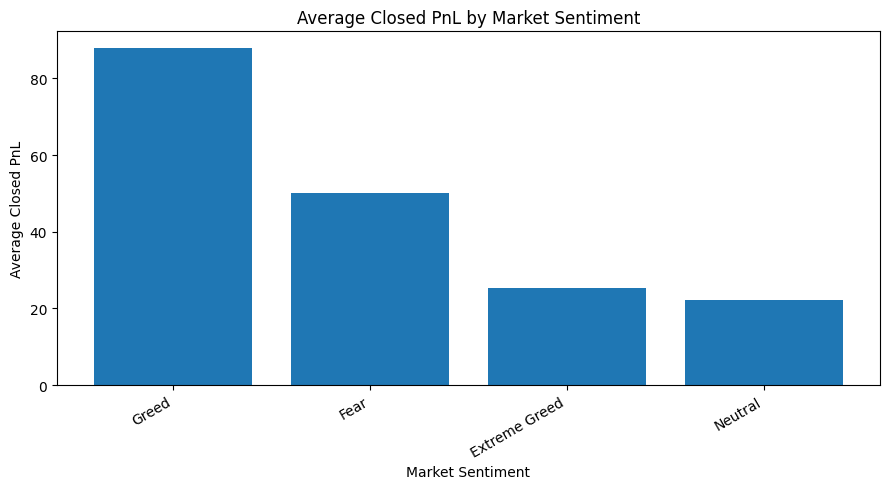

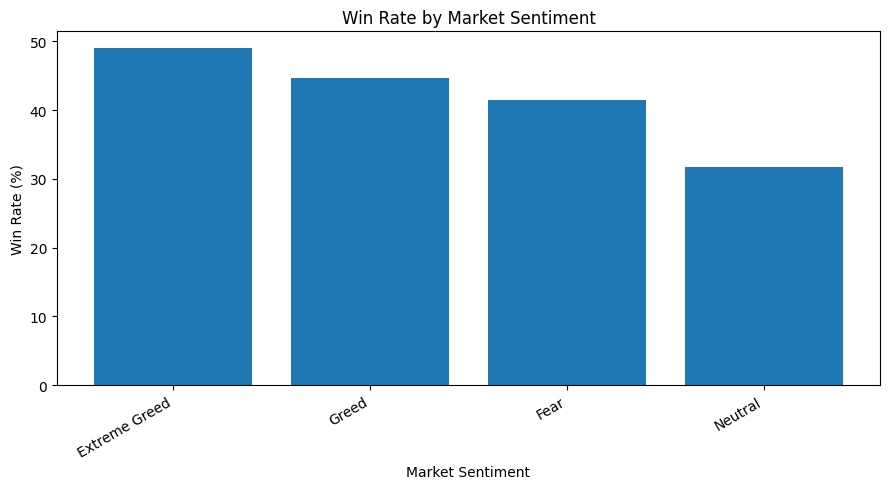

In [30]:
# Plot: Average PnL by sentiment
plot_df = sentiment_summary.sort_values("avg_pnl", ascending=False)
plt.figure(figsize=(9, 5))
plt.bar(plot_df["classification"], plot_df["avg_pnl"])
plt.title("Average Closed PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "avg_pnl_by_sentiment.png", dpi=200)
plt.show()

# Plot: Win Rate by sentiment
plot_df = sentiment_summary.sort_values("win_rate", ascending=False)
plt.figure(figsize=(9, 5))
plt.bar(plot_df["classification"], plot_df["win_rate"])
plt.title("Win Rate by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Win Rate (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "win_rate_by_sentiment.png", dpi=200)
plt.show()

,classification,side_clean,trades,unique_accounts,unique_symbols,total_pnl,avg_pnl,median_pnl,win_rate,total_volume_usd,avg_size_usd,avg_leverage,total_fee
2,Fear,Buy,66081,31,141,3.837630e+06,58.074630,0.000000,26.104327,3.537757e+08,5353.668101,NaN,71449.748758
5,Greed,Sell,20868,27,128,2.997016e+06,143.617782,1.722882,61.328350,5.936053e+07,2844.572016,NaN,13627.624235
3,Fear,Sell,67790,32,150,2.862296e+06,42.222976,0.449315,56.536362,3.503828e+08,5168.649524,NaN,73568.294860
4,Greed,Buy,15421,27,117,1.926007e+05,12.489506,0.000000,22.073795,5.614314e+07,3640.694056,NaN,10706.409154
7,Neutral,Sell,3636,8,77,1.039028e+05,28.576120,0.000000,24.642464,1.093852e+07,3008.394626,NaN,3682.930422
1,Extreme Greed,Sell,3591,4,72,9.074015e+04,25.268770,0.147000,52.130326,1.982847e+07,5521.712718,NaN,3420.370090
0,Extreme Greed,Buy,3371,5,72,8.622534e+04,25.578564,0.000000,45.683773,1.957830e+07,5807.861133,NaN,3392.411143
6,Neutral,Buy,3505,8,42,5.483961e+04,15.646108,0.000000,39.058488,1.090471e+07,3111.187301,NaN,5060.947064


side_clean,Buy,Sell
classification,,
Extreme Greed,25.578564,25.268770
Fear,58.074630,42.222976
Greed,12.489506,143.617782
Neutral,15.646108,28.576120


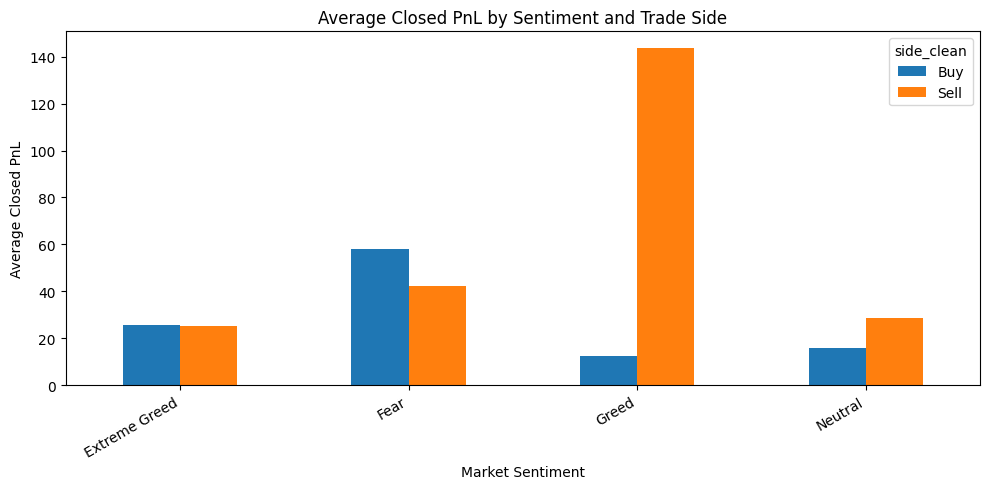

In [31]:
side_sentiment_summary = summarize_performance(analysis_df, ["classification", "side_clean"])
display(side_sentiment_summary)
side_sentiment_summary.to_csv(OUTPUT_DIR / "side_sentiment_summary.csv", index=False)

pivot_side = side_sentiment_summary.pivot_table(
    index="classification", columns="side_clean", values="avg_pnl", aggfunc="mean"
)
display(pivot_side)

pivot_side.plot(kind="bar", figsize=(10, 5))
plt.title("Average Closed PnL by Sentiment and Trade Side")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "avg_pnl_by_sentiment_side.png", dpi=200)
plt.show()

In [32]:
if analysis_df["leverage"].notna().sum() > 0:
    analysis_df["leverage_bucket"] = pd.cut(
        analysis_df["leverage"],
        bins=[-np.inf, 3, 10, 25, np.inf],
        labels=["Low ≤3x", "Medium 3–10x", "High 10–25x", "Very High >25x"]
    )
    leverage_summary = summarize_performance(analysis_df.dropna(subset=["leverage_bucket"]), ["classification", "leverage_bucket"])
    display(leverage_summary)
    leverage_summary.to_csv(OUTPUT_DIR / "leverage_sentiment_summary.csv", index=False)

    pivot_lev = leverage_summary.pivot_table(
        index="classification", columns="leverage_bucket", values="avg_pnl", aggfunc="mean"
    )
    display(pivot_lev)

    pivot_lev.plot(kind="bar", figsize=(11, 5))
    plt.title("Average PnL by Sentiment and Leverage Bucket")
    plt.xlabel("Market Sentiment")
    plt.ylabel("Average Closed PnL")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "avg_pnl_by_sentiment_leverage.png", dpi=200)
    plt.show()
else:
    print("No usable leverage column found.")

No usable leverage column found.


In [33]:
account_sentiment_summary = summarize_performance(analysis_df, ["account_clean", "classification"])

MIN_TRADES = 10
account_sentiment_filtered = account_sentiment_summary[account_sentiment_summary["trades"] >= MIN_TRADES].copy()

display(account_sentiment_filtered.sort_values("total_pnl", ascending=False).head(20))
display(account_sentiment_filtered.sort_values("total_pnl", ascending=True).head(20))

account_sentiment_summary.to_csv(OUTPUT_DIR / "account_sentiment_summary.csv", index=False)
account_sentiment_filtered.to_csv(OUTPUT_DIR / "account_sentiment_summary_min10.csv", index=False)

,account_clean,classification,trades,unique_accounts,unique_symbols,total_pnl,avg_pnl,median_pnl,win_rate,total_volume_usd,avg_size_usd,avg_leverage,total_fee
0,0x083384f897ee0f19899168e3b1bec365f52a9012,Fear,3356,1,2,1.927736e+06,574.414696,0.000000,40.554231,5.485463e+07,16345.241940,NaN,6292.416654
66,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,2311,1,28,1.421911e+06,615.279684,0.000000,43.530939,1.425600e+07,6168.758897,NaN,3595.639896
69,0xbaaaf6571ab7d571043ff1e313a9609a10637864,Fear,21190,1,3,9.401572e+05,44.367967,0.000000,46.753185,6.803633e+07,3210.775186,NaN,8596.700755
73,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,Greed,9883,1,14,6.842150e+05,69.231509,0.445050,56.926035,2.661772e+07,2693.283796,NaN,2512.007331
27,0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,Fear,3806,1,10,6.133278e+05,161.147616,0.000000,49.527063,3.424772e+07,8998.349073,NaN,6908.119765
65,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Fear,7380,1,13,5.538180e+05,75.043089,0.000000,39.105691,1.342117e+07,1818.587241,NaN,4707.649021
33,0x513b8629fe877bb581bf244e326a047b249c4ff1,Fear,5777,1,4,4.035016e+05,69.846226,0.000000,41.561364,1.635148e+08,28304.445063,NaN,28156.730616
39,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,Fear,939,1,25,3.419454e+05,364.159142,0.000000,39.616613,1.993873e+06,2123.400266,NaN,188.513388
38,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,Greed,202,1,1,3.275460e+05,1621.514851,16.013360,51.485149,3.294850e+06,16311.138465,NaN,329.484916
70,0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3,Fear,2211,1,26,3.254420e+05,147.192210,0.000000,37.222976,1.791788e+07,8103.972913,NaN,3999.853932


,account_clean,classification,trades,unique_accounts,unique_symbols,total_pnl,avg_pnl,median_pnl,win_rate,total_volume_usd,avg_size_usd,avg_leverage,total_fee
1,0x083384f897ee0f19899168e3b1bec365f52a9012,Greed,462,1,2,-327505.900056,-708.887230,0.0,2.597403,6842632.02,14810.891818,NaN,1112.895650
12,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,Fear,349,1,9,-59349.677108,-170.056381,0.0,26.361032,575346.58,1648.557536,NaN,56.287755
32,0x4f93fead39b70a1824f981a54d4e55b278e9f760,Neutral,1309,1,22,-25991.506339,-19.856002,0.0,33.155080,13339126.17,10190.317930,NaN,4668.693244
15,0x39cef799f8b69da1995852eea189df24eb5cae3c,Fear,3445,1,11,-20526.462526,-5.958335,0.0,31.930334,16537484.20,4800.430827,NaN,1319.000440
59,0xa520ded057a32086c40e7dd6ed4eb8efb82c00e0,Neutral,39,1,4,-14505.505750,-371.936045,0.0,0.000000,307215.74,7877.326667,NaN,138.243995
52,0x8477e447846c758f5a675856001ea72298fd9cb5,Neutral,3810,1,30,-9125.157325,-2.395054,0.0,32.545932,2942740.70,772.372887,NaN,903.689727
29,0x4f93fead39b70a1824f981a54d4e55b278e9f760,Extreme Greed,730,1,1,-7919.471032,-10.848590,0.0,30.684932,4540452.90,6219.798493,NaN,1589.158168
11,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,Extreme Greed,27,1,4,-5564.016140,-206.074672,0.0,33.333333,82312.05,3048.594444,NaN,3.902580
21,0x430f09841d65beb3f27765503d0f850b8bce7713,Extreme Greed,88,1,1,0.000000,0.000000,0.0,0.000000,99995.52,1136.312727,NaN,253.106010
47,0x8170715b3b381dffb7062c0298972d4727a0a63b,Greed,15,1,1,0.000000,0.000000,0.0,0.000000,34998.80,2333.253333,NaN,0.129590


In [34]:
# Best sentiment per account based on avg PnL, after filtering low sample sizes
best_account_sentiment = (
    account_sentiment_filtered
    .sort_values(["account_clean", "avg_pnl"], ascending=[True, False])
    .groupby("account_clean")
    .head(1)
    .sort_values("avg_pnl", ascending=False)
)

display(best_account_sentiment.head(20))
best_account_sentiment.to_csv(OUTPUT_DIR / "best_sentiment_per_account.csv", index=False)

,account_clean,classification,trades,unique_accounts,unique_symbols,total_pnl,avg_pnl,median_pnl,win_rate,total_volume_usd,avg_size_usd,avg_leverage,total_fee
23,0x430f09841d65beb3f27765503d0f850b8bce7713,Greed,43,1,7,1.604505e+05,3731.407398,1068.426276,88.372093,2.899370e+05,6742.719767,NaN,101.476704
38,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,Greed,202,1,1,3.275460e+05,1621.514851,16.013360,51.485149,3.294850e+06,16311.138465,NaN,329.484916
19,0x420ab45e0bd8863569a5efbb9c05d91f40624641,Fear,258,1,8,1.834030e+05,710.864435,0.000000,24.418605,1.177449e+06,4563.756163,NaN,137.559496
66,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,2311,1,28,1.421911e+06,615.279684,0.000000,43.530939,1.425600e+07,6168.758897,NaN,3595.639896
0,0x083384f897ee0f19899168e3b1bec365f52a9012,Fear,3356,1,2,1.927736e+06,574.414696,0.000000,40.554231,5.485463e+07,16345.241940,NaN,6292.416654
36,0x6d6a4b953f202f8df5bed40692e7fd865318264a,Greed,250,1,1,1.015393e+05,406.157096,275.362103,100.000000,1.313678e+05,525.471360,NaN,36.926673
39,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,Fear,939,1,25,3.419454e+05,364.159142,0.000000,39.616613,1.993873e+06,2123.400266,NaN,188.513388
17,0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6,Fear,141,1,3,4.588363e+04,325.415808,0.609300,56.028369,6.116890e+05,4338.219787,NaN,64.694298
16,0x39cef799f8b69da1995852eea189df24eb5cae3c,Greed,144,1,6,3.498338e+04,242.940152,1.546349,52.777778,6.558912e+05,4554.800139,NaN,139.656686
58,0xa520ded057a32086c40e7dd6ed4eb8efb82c00e0,Greed,283,1,7,6.790025e+04,239.930203,3.894186,54.770318,4.766293e+05,1684.202580,NaN,29.200864


In [35]:
symbol_sentiment_summary = summarize_performance(analysis_df, ["symbol_clean", "classification"])
symbol_sentiment_filtered = symbol_sentiment_summary[symbol_sentiment_summary["trades"] >= MIN_TRADES].copy()

display(symbol_sentiment_filtered.sort_values("total_pnl", ascending=False).head(20))
display(symbol_sentiment_filtered.sort_values("avg_pnl", ascending=False).head(20))

symbol_sentiment_summary.to_csv(OUTPUT_DIR / "symbol_sentiment_summary.csv", index=False)
symbol_sentiment_filtered.to_csv(OUTPUT_DIR / "symbol_sentiment_summary_min10.csv", index=False)

,symbol_clean,classification,trades,unique_accounts,unique_symbols,total_pnl,avg_pnl,median_pnl,win_rate,total_volume_usd,avg_size_usd,avg_leverage,total_fee
7,@107,Greed,13687,22,1,2.587377e+06,189.038983,0.633446,56.184701,3.017330e+07,2204.522414,NaN,2449.874877
230,HYPE,Fear,57236,19,1,1.835061e+06,32.061303,0.000000,42.019009,1.242075e+08,2170.093133,NaN,22524.827524
195,ETH,Fear,5372,14,1,1.445276e+06,269.038782,0.000000,46.388682,6.512208e+07,12122.500985,NaN,9390.179868
363,SOL,Fear,7004,16,1,1.372565e+06,195.968687,0.000000,41.233581,8.171647e+07,11667.113989,NaN,17570.025660
163,BTC,Fear,16168,18,1,5.521138e+05,34.148555,0.000000,35.663038,3.503168e+08,21667.293166,NaN,78999.268530
287,MELANIA,Fear,3322,9,1,3.168006e+05,95.364410,0.000000,33.594220,5.637548e+06,1697.034380,NaN,761.598833
190,ENA,Fear,651,3,1,2.044611e+05,314.072349,0.000000,33.640553,1.059976e+06,1628.227573,NaN,204.146899
6,@107,Fear,13698,22,1,1.895210e+05,13.835667,0.000000,39.524018,2.361753e+07,1724.159277,NaN,3254.775361
436,ZRO,Neutral,1146,2,1,1.438087e+05,125.487554,0.000000,33.246073,8.845544e+05,771.862469,NaN,151.459204
375,SUI,Fear,1142,5,1,1.279619e+05,112.050670,0.000000,44.308231,4.702498e+06,4117.774221,NaN,1177.073015


,symbol_clean,classification,trades,unique_accounts,unique_symbols,total_pnl,avg_pnl,median_pnl,win_rate,total_volume_usd,avg_size_usd,avg_leverage,total_fee
435,ZRO,Greed,23,1,1,3.616557e+04,1572.416058,1147.561968,100.000000,165648.12,7202.092174,NaN,57.976841
178,DOGE,Fear,348,5,1,1.266616e+05,363.970027,0.000000,45.689655,650306.04,1868.695517,NaN,215.305363
190,ENA,Fear,651,3,1,2.044611e+05,314.072349,0.000000,33.640553,1059976.15,1628.227573,NaN,204.146899
138,AVAX,Fear,119,5,1,3.606151e+04,303.037937,0.335016,51.260504,283938.40,2386.036975,NaN,77.737176
8,@109,Fear,18,4,1,5.386517e+03,299.250918,423.702974,72.222222,5632.96,312.942222,NaN,3.992105
103,@85,Greed,60,2,1,1.696672e+04,282.778663,0.000000,35.000000,24622.54,410.375667,NaN,7.393758
286,ME,Greed,10,1,1,2.767027e+03,276.702671,36.311615,80.000000,82767.39,8276.739000,NaN,8.874560
195,ETH,Fear,5372,14,1,1.445276e+06,269.038782,0.000000,46.388682,65122075.29,12122.500985,NaN,9390.179868
188,EIGEN,Greed,237,3,1,5.171152e+04,218.192070,0.000000,16.033755,326368.85,1377.083755,NaN,42.509312
363,SOL,Fear,7004,16,1,1.372565e+06,195.968687,0.000000,41.233581,81716466.38,11667.113989,NaN,17570.025660


In [36]:
try:
    from scipy.stats import mannwhitneyu

    classes = analysis_df["classification"].dropna().unique().tolist()
    pairs = []
    for i in range(len(classes)):
        for j in range(i + 1, len(classes)):
            a = analysis_df.loc[analysis_df["classification"] == classes[i], "closed_pnl"].dropna()
            b = analysis_df.loc[analysis_df["classification"] == classes[j], "closed_pnl"].dropna()
            if len(a) >= 10 and len(b) >= 10:
                stat, p = mannwhitneyu(a, b, alternative="two-sided")
                pairs.append({
                    "sentiment_a": classes[i],
                    "sentiment_b": classes[j],
                    "n_a": len(a),
                    "n_b": len(b),
                    "median_a": a.median(),
                    "median_b": b.median(),
                    "p_value": p,
                })

    stats_df = pd.DataFrame(pairs).sort_values("p_value")
    display(stats_df)
    stats_df.to_csv(OUTPUT_DIR / "sentiment_statistical_tests.csv", index=False)
except Exception as e:
    print("Statistical test skipped:", e)

,sentiment_a,sentiment_b,n_a,n_b,median_a,median_b,p_value
2,Greed,Neutral,36289,7141,0.0,0.0,2.967812e-66
5,Extreme Greed,Neutral,6962,7141,0.0,0.0,4.519266e-47
4,Fear,Neutral,133871,7141,0.0,0.0,3.781293e-45
0,Greed,Fear,36289,133871,0.0,0.0,1.350798e-25
3,Fear,Extreme Greed,133871,6962,0.0,0.0,2.486535e-15
1,Greed,Extreme Greed,36289,6962,0.0,0.0,1.056997e-02


In [37]:
def safe_top(df, metric, ascending=False):
    if df.empty or metric not in df.columns:
        return None
    return df.sort_values(metric, ascending=ascending).iloc[0]

best_avg_sent = safe_top(sentiment_summary, "avg_pnl", ascending=False)
best_total_sent = safe_top(sentiment_summary, "total_pnl", ascending=False)
best_win_sent = safe_top(sentiment_summary, "win_rate", ascending=False)
worst_avg_sent = safe_top(sentiment_summary, "avg_pnl", ascending=True)

findings = []
findings.append("Key Findings: Trader Performance vs Market Sentiment")
findings.append(f"Total matched trades analyzed: {len(analysis_df):,}")
findings.append(f"Date range analyzed: {analysis_df['date'].min()} to {analysis_df['date'].max()}")

if best_avg_sent is not None:
    findings.append(
        f"1.Highest average PnL was observed during **{best_avg_sent['classification']}sentiment "
        f"with average closed PnL of {best_avg_sent['avg_pnl']:.4f} across {int(best_avg_sent['trades']):,} trades."
    )
if best_total_sent is not None:
    findings.append(
        f"2.Highest total PnL came from **{best_total_sent['classification']}sentiment "
        f"with total closed PnL of {best_total_sent['total_pnl']:.4f}."
    )
if best_win_sent is not None:
    findings.append(
        f"3.Best win rate appeared during **{best_win_sent['classification']} sentiment "
        f"with a win rate of {best_win_sent['win_rate']:.2f}%."
    )
if worst_avg_sent is not None:
    findings.append(
        f"4.Weakest average PnL was observed during {worst_avg_sent['classification']} sentiment "
        f"with average closed PnL of {worst_avg_sent['avg_pnl']:.4f}."
    )

# Side insight
if 'side_sentiment_summary' in globals() and not side_sentiment_summary.empty:
    top_side = side_sentiment_summary[side_sentiment_summary['trades'] >= MIN_TRADES].sort_values('avg_pnl', ascending=False).head(1)
    if len(top_side):
        r = top_side.iloc[0]
        findings.append(
            f"5. The strongest side/sentiment combination was **{r['side_clean']} during {r['classification']}**, "
            f"with average PnL of {r['avg_pnl']:.4f} across {int(r['trades']):,} trades."
        )

# Leverage insight
if 'leverage_summary' in globals() and not leverage_summary.empty:
    top_lev = leverage_summary[leverage_summary['trades'] >= MIN_TRADES].sort_values('avg_pnl', ascending=False).head(1)
    if len(top_lev):
        r = top_lev.iloc[0]
        findings.append(
            f"6. The best leverage/sentiment bucket was **{r['leverage_bucket']} during {r['classification']}**, "
            f"with average PnL of {r['avg_pnl']:.4f}."
        )

findings.append("## Strategy Recommendations")
findings.append("- Use sentiment as a context feature, not as a standalone signal. Compare trade direction, leverage, and symbol behavior within each sentiment state.")
findings.append("- Reduce or cap leverage in sentiment states where average PnL and win rate are both weak.")
findings.append("- Identify accounts with stable profitability across multiple sentiment states and study their sizing, side preference, and symbol selection.")
findings.append("- For production use, validate these patterns out-of-sample before applying them to live trading decisions.")

report_text = "".join(findings)
print(report_text)

with open(OUTPUT_DIR / "key_findings.md", "w", encoding="utf-8") as f:
    f.write(report_text)

Key Findings: Trader Performance vs Market SentimentTotal matched trades analyzed: 184,263Date range analyzed: 2023-03-28 to 2025-02-191.Highest average PnL was observed during **Greedsentiment with average closed PnL of 87.8949 across 36,289 trades.2.Highest total PnL came from **Fearsentiment with total closed PnL of 6699925.1906.3.Best win rate appeared during **Extreme Greed sentiment with a win rate of 49.01%.4.Weakest average PnL was observed during Neutral sentiment with average closed PnL of 22.2297.5. The strongest side/sentiment combination was **Sell during Greed**, with average PnL of 143.6178 across 20,868 trades.## Strategy Recommendations- Use sentiment as a context feature, not as a standalone signal. Compare trade direction, leverage, and symbol behavior within each sentiment state.- Reduce or cap leverage in sentiment states where average PnL and win rate are both weak.- Identify accounts with stable profitability across multiple sentiment states and study their sizin

In [38]:
import os

print(os.listdir())

['.config', 'data', 'outputs', 'sample_data']


In [39]:
os.listdir("outputs")

['avg_pnl_by_sentiment.png',
 'side_sentiment_summary.csv',
 'account_sentiment_summary.csv',
 'symbol_sentiment_summary_min10.csv',
 'account_sentiment_summary_min10.csv',
 'sentiment_statistical_tests.csv',
 'best_sentiment_per_account.csv',
 'symbol_sentiment_summary.csv',
 'key_findings.md',
 'avg_pnl_by_sentiment_side.png',
 'win_rate_by_sentiment.png',
 'sentiment_performance_summary.csv']

In [40]:
!zip -r primetrade_outputs.zip outputs


  adding: outputs/ (stored 0%)
  adding: outputs/avg_pnl_by_sentiment.png (deflated 23%)
  adding: outputs/side_sentiment_summary.csv (deflated 43%)
  adding: outputs/account_sentiment_summary.csv (deflated 54%)
  adding: outputs/symbol_sentiment_summary_min10.csv (deflated 53%)
  adding: outputs/account_sentiment_summary_min10.csv (deflated 53%)
  adding: outputs/sentiment_statistical_tests.csv (deflated 49%)
  adding: outputs/best_sentiment_per_account.csv (deflated 45%)
  adding: outputs/symbol_sentiment_summary.csv (deflated 56%)
  adding: outputs/key_findings.md (deflated 48%)
  adding: outputs/avg_pnl_by_sentiment_side.png (deflated 21%)
  adding: outputs/win_rate_by_sentiment.png (deflated 24%)
  adding: outputs/sentiment_performance_summary.csv (deflated 38%)


In [41]:
from google.colab import files
files.download("primetrade_outputs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>